# 基于 RNA velocity 的 CellRank 分析

本教程使用胰腺 RNA velocity 数据展示 CellRank 分析流程。内容包括 velocity 预处理、terminal state 识别、fate probability 计算、分支伪时间可视化，以及 marker gene 动态趋势分析。

## 加载数据

这里使用 `scvelo` 提供的 pancreas 发育数据。该数据包含 RNA velocity 分析所需的 `spliced` 和 `unspliced` layer。

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
import scanpy as sc
import scvelo as scv
import cellrank as cr
import numpy as np
import matplotlib.pyplot as plt

ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc: Can not load face (locations (loca) table missing; error code 0x90)


INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/Fonts/SFIndia.ttc: Can not load face (SFNT font table missing; error code 0x8e)


INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/Fonts/LastResort.otf: tuple indices must be integers or slices, not str


INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/Fonts/Supplemental/NISC18030.ttf: Could not set the fontsize (invalid pixel size; error code 0x17)


INFO:matplotlib.font_manager:Failed to extract font properties from /System/Library/Fonts/Apple Color Emoji.ttc: Could not set the fontsize (invalid pixel size; error code 0x17)


Registered as: Arial
🧬 Detecting GPU devices…
🚫 PyTorch not available - GPU detection skipped

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata = scv.datasets.pancreas()
adata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

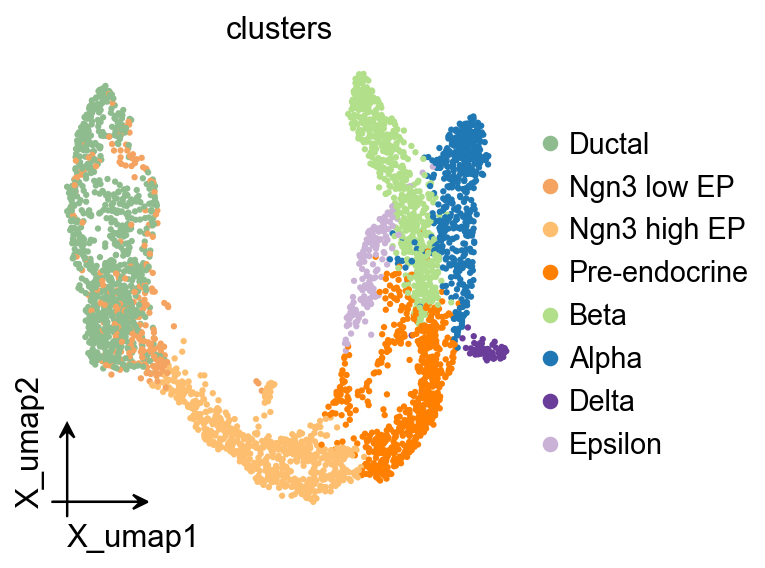

In [3]:
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='clusters',
    frameon='small',
)

## 估计 RNA velocity

这里我们保持一个紧凑但完整的预处理流程：先做共享计数归一化，再计算 PCA 和邻居图，然后估计 moments、deterministic velocity，以及后续 CellRank 需要的 velocity graph。后续分支和 marker program 可视化会使用面向发育过程的 pseudotime。


In [4]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20)
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)
scv.tl.velocity(adata, mode='deterministic')
scv.tl.velocity_graph(adata, n_jobs=1)
scv.tl.velocity_pseudotime(adata)

root_mask = adata.obs['clusters'].astype(str).eq('Ductal')
if not root_mask.any():
    root_mask = adata.obs['clusters'].astype(str).eq('Ngn3 low EP')
root_cells = np.flatnonzero(root_mask.to_numpy())
root_center = np.asarray(adata.obsm['X_pca'][root_cells]).mean(axis=0)
root_index = int(
    root_cells[
        np.argmin(
            np.linalg.norm(adata.obsm['X_pca'][root_cells] - root_center, axis=1)
        )
    ]
)
adata.uns['iroot'] = root_index
sc.tl.diffmap(adata)
sc.tl.dpt(adata, n_dcs=10)
adata.obs['development_pseudotime'] = adata.obs['dpt_pseudotime']


Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.


computing moments based on connectivities


    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/12 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:05) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


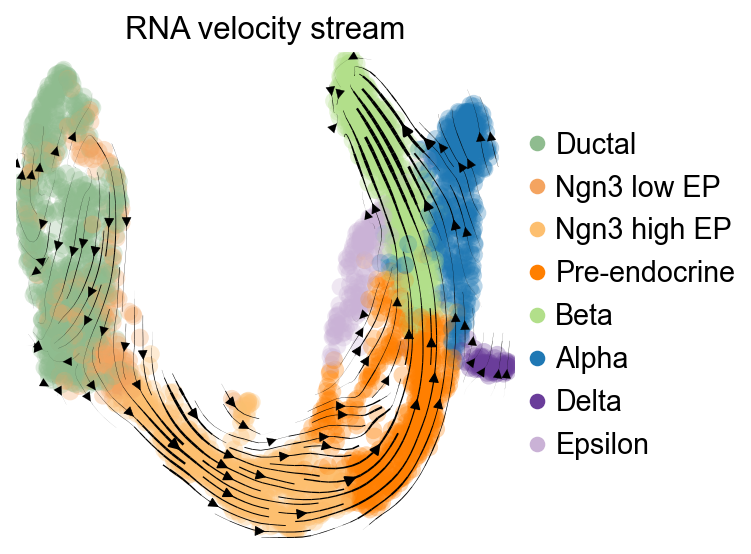

In [5]:
scv.pl.velocity_embedding_stream(
    adata,
    basis='umap',
    color='clusters',
    legend_loc='right',
    title='RNA velocity stream',
)

## 构建 CellRank kernel

一个常见做法是将基于 velocity 的转移信息与邻接图连接关系做线性组合，让后续 fate 分析同时利用局部图结构和 RNA velocity 方向。

In [6]:
vk = cr.kernels.VelocityKernel(adata).compute_transition_matrix()
ck = cr.kernels.ConnectivityKernel(adata).compute_transition_matrix()
kernel = 0.8 * vk + 0.2 * ck
kernel

  0%|          | 0/3696 [00:00<?, ?cell/s]

  0%|          | 0/3696 [00:00<?, ?cell/s]

(0.8 * VelocityKernel[n=3696, model='deterministic', similarity='correlation', softmax_scale=12.543] + 0.2 * ConnectivityKernel[n=3696, dnorm=True, key='connectivities'])

## 可视化 CellRank velocity kernel

构建 CellRank velocity kernel 之后，可以把它的转移方向投影回 UMAP，用于检查 fate 分析所使用的方向信息。

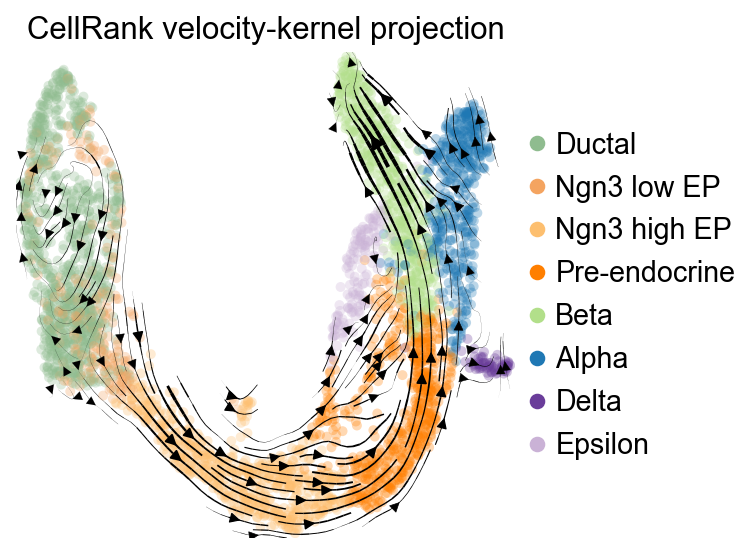

In [7]:
vk.plot_projection(
    basis='umap',
    color='clusters',
    legend_loc='right',
    title='CellRank velocity-kernel projection',
    stream=True,
    size=80,
)


## OV 轨迹图叠加

面向发育方向的 pseudotime 可以作为 PAGA 的时间先验，得到一张与 velocity stream 和 CellRank kernel projection 互补的图结构叠加。

running PAGA using priors: ['development_pseudotime']


    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


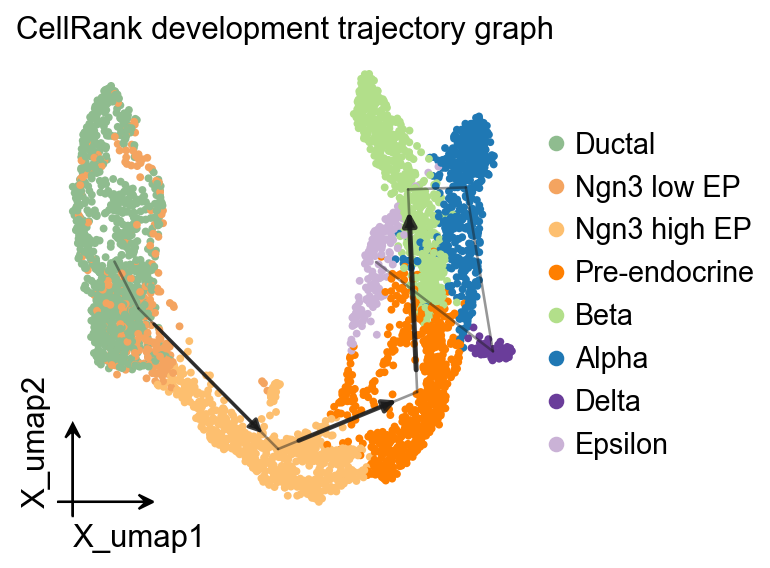

In [8]:
ov.utils.cal_paga(
    adata,
    use_time_prior='development_pseudotime',
    vkey='velocity',
    groups='clusters',
)
ov.pl.trajectory(
    adata,
    method='paga',
    basis='X_umap',
    groups='clusters',
    color='clusters',
    title='CellRank development trajectory graph',
)
plt.show()


## OV 轨迹叠加

`ov.pl.trajectory_overlay` 可以把 PAGA 骨架叠加到已有 UMAP embedding 上。

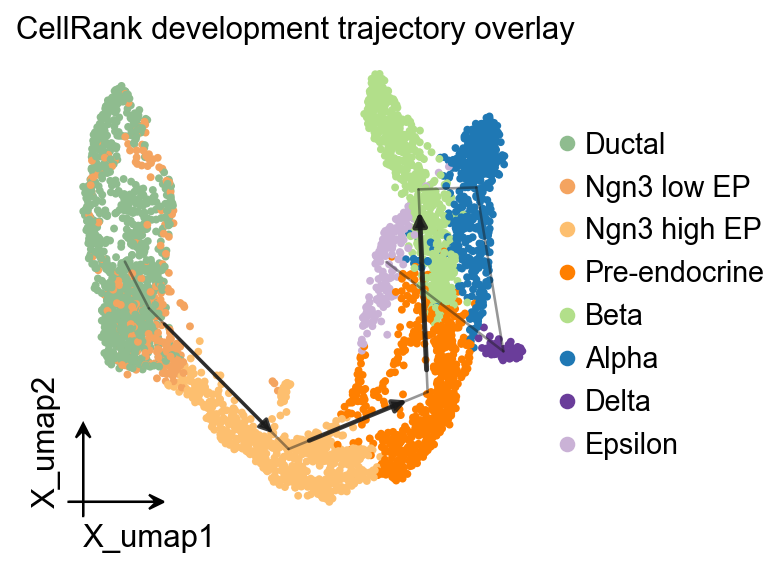

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='clusters',
    ax=ax,
    show=False,
    size=50,
)
ov.pl.trajectory_overlay(
    adata,
    ax=ax,
    method='paga',
    basis='X_umap',
    groups='clusters',
)
ax.set_title('CellRank development trajectory overlay')
plt.show()


In [10]:
g = cr.estimators.GPCCA(kernel)
g.compute_macrostates(n_states=6, cluster_key='clusters')
list(g.macrostates.cat.categories)

INFO:root:Using pre-computed Schur decomposition


['Epsilon', 'Alpha', 'Ductal_1', 'Ductal_2', 'Ngn3 high EP', 'Beta']

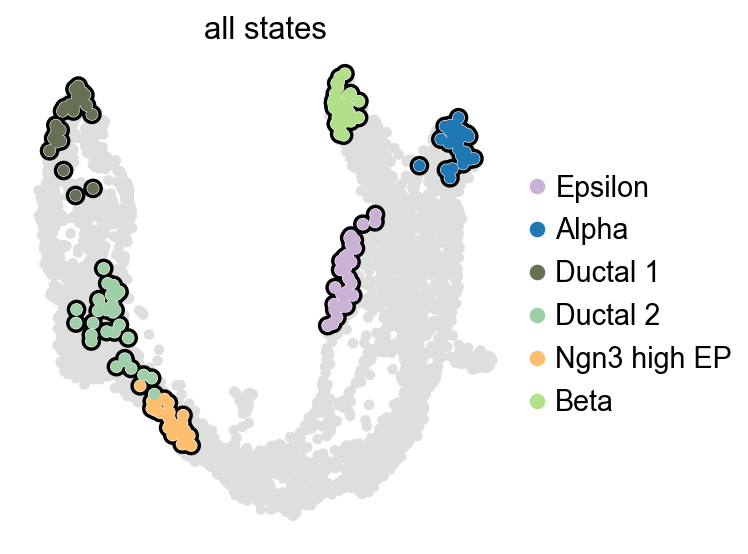

In [11]:
g.plot_macrostates(which='all', legend_loc='right', size=90)

## 识别终末状态并计算命运概率

在这个胰腺示例中，CellRank 可以根据已经拟合好的 macrostates 自动提出 terminal states。随后我们为每个细胞计算 lineage fate probabilities。

In [12]:
g.predict_terminal_states(n_states=4)
list(g.terminal_states.cat.categories)

['Epsilon', 'Alpha', 'Beta']

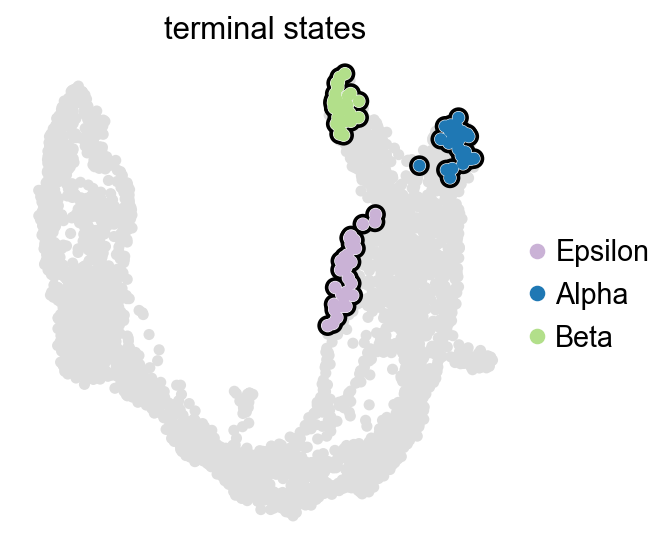

In [13]:
g.plot_macrostates(which='terminal', legend_loc='right', size=100)

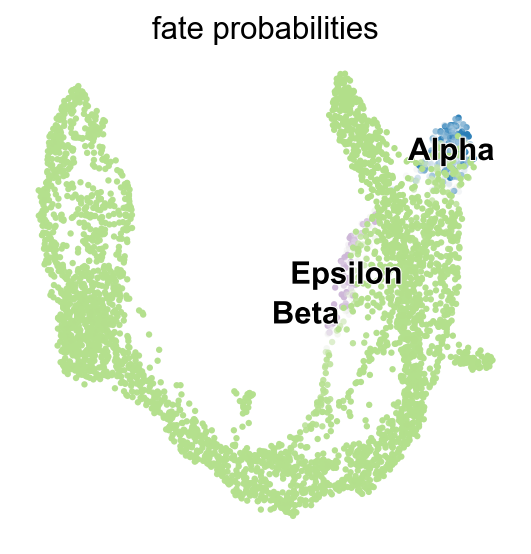

In [14]:
g.compute_fate_probabilities(solver='direct', use_petsc=False)
g.plot_fate_probabilities(same_plot=True)

In [15]:
adata.obs.groupby('clusters', observed=True)[
    ['velocity_pseudotime', 'development_pseudotime']
].median().sort_values('development_pseudotime')


               velocity_pseudotime  development_pseudotime
clusters                                                  
Ngn3 low EP               0.911242                0.039220
Ductal                    0.908973                0.043246
Ngn3 high EP              0.937826                0.347985
Pre-endocrine             0.944476                0.634166
Beta                      0.950648                0.774505
Epsilon                   0.633200                0.796823
Alpha                     0.911853                0.819963
Delta                     0.898328                0.845001

## 沿 development pseudotime 绘制 branch-aware stream plot

`ov.pl.branch_streamplot` 可以直接使用 root-oriented development pseudotime 和胰腺 cluster 标签。共享的 endocrine progenitor 状态会形成主干，后续终末 endocrine fate 则展开成分支 ribbon，从而把 UMAP 上的速度场和 CellRank 的命运概率连接到一张更紧凑的图里。


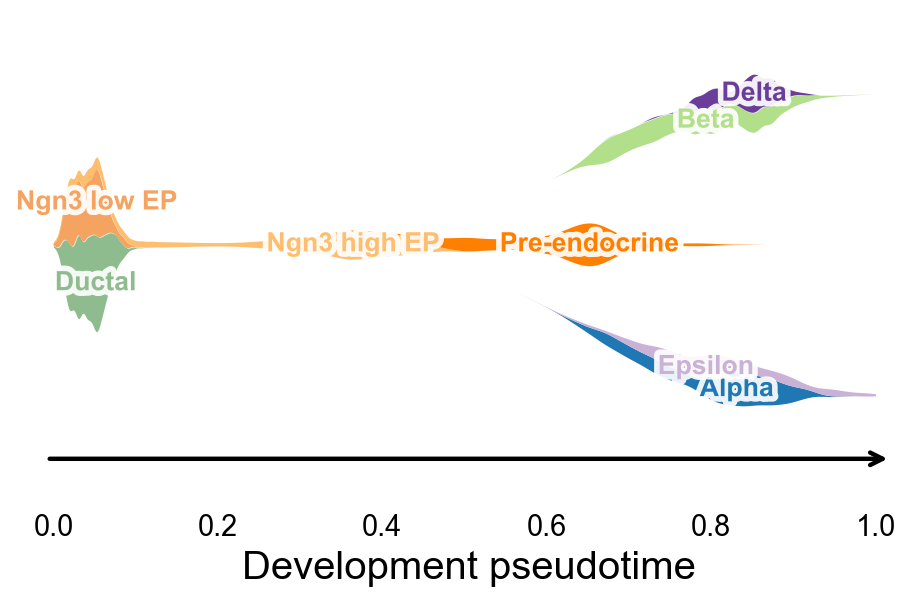

In [16]:
fig, ax = ov.pl.branch_streamplot(
    adata,
    group_key='clusters',
    pseudotime_key='development_pseudotime',
    trunk_groups=['Ductal', 'Ngn3 low EP', 'Ngn3 high EP', 'Pre-endocrine'],
    branch_center=0.62,
    figsize=(6, 4),
    xlabel='Development pseudotime',
    show=False,
)
plt.show()


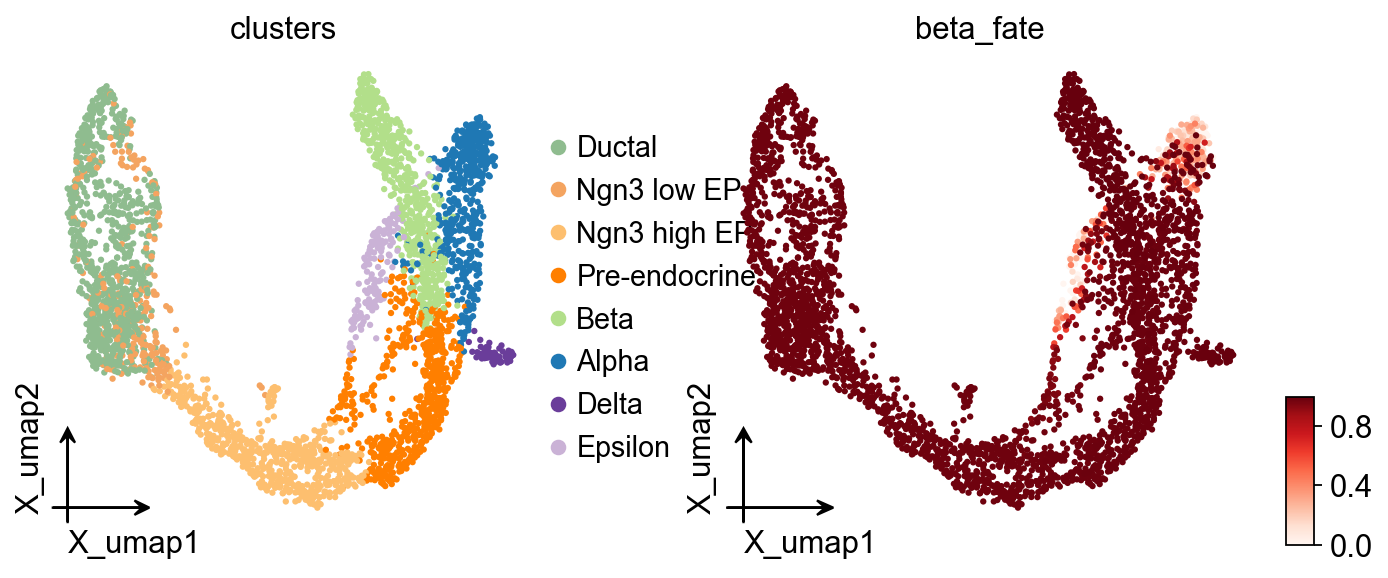

In [17]:
adata.obs['beta_fate'] = np.asarray(g.fate_probabilities['Beta']).ravel()
ov.pl.embedding(
    adata,
    basis='X_umap',
    color=['clusters', 'beta_fate'],
    cmap='Reds',
    frameon='small',
)

## 查看 lineage-specific 基因趋势

`ov.single.dynamic_features` 可以沿 `development_pseudotime` 拟合 GAM 趋势，而 `ov.pl.dynamic_trends` 在这里可以展示两种互补视角。第一种是 Beta 富集细胞上的全局趋势图，并用 cluster 给原始散点着色；第二种是 Alpha / Beta 分支比较图。

In [18]:
safe_uns = {k: v for k, v in adata.uns.items() if k.endswith('_colors') or k in {'neighbors', 'umap'}}
uns_backup = adata.uns
adata.uns = safe_uns
adata_dyn = adata.copy()
adata.uns = uns_backup

adata_beta = adata_dyn[adata_dyn.obs['beta_fate'] > 0.15].copy()

beta_dyn = ov.single.dynamic_features(
    adata_beta,
    genes=['Pdx1', 'Ins1', 'Ins2', 'Sox9'],
    pseudotime='development_pseudotime',
    layer='Ms',
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['clusters'],
)



🔍 Dynamic feature analysis:
   Views: 1 | Features: 4
   Pseudotime: development_pseudotime
   Stored raw obs keys: ['clusters']
   Layer: Ms
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/4 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 4/4
   ✓ Fitted rows: 800
   ✓ Raw observations stored: 14380



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False


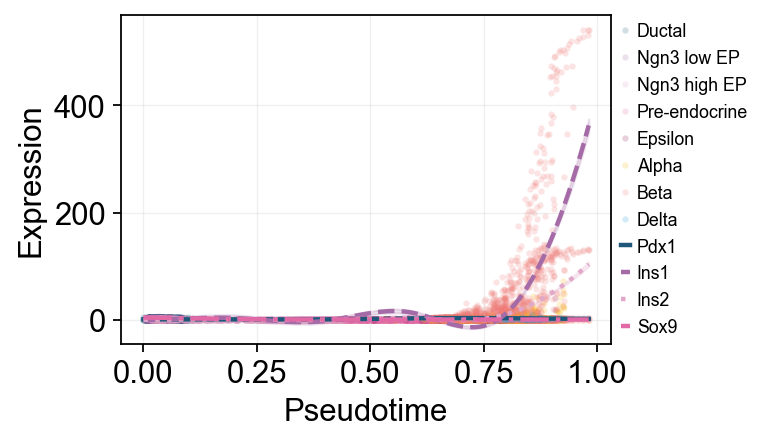

✅ Dynamic trend plotting completed!


In [19]:
ov.pl.dynamic_trends(
    beta_dyn,
    genes=['Pdx1', 'Ins1', 'Ins2', 'Sox9'],
    compare_features=True,
    add_point=True,
    point_color_by='clusters',
    line_style_by='features',
    figsize=(6, 3),
    linewidth=2,
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

In [20]:
branch_clusters = [g for g in ['Alpha', 'Beta'] if g in set(adata_dyn.obs['clusters'].astype(str))]
split_mask = adata_dyn.obs['clusters'].astype(str).isin(['Ngn3 high EP', 'Pre-endocrine'])

cellrank_branch_dyn = None
cellrank_split_time = None

if len(branch_clusters) >= 2:
    cellrank_branch_dyn = ov.single.dynamic_features(
        adata_dyn,
        genes=['Gcg', 'Ins1', 'Ins2', 'Pdx1'],
        pseudotime='development_pseudotime',
        layer='Ms',
        groupby='clusters',
        groups=branch_clusters,
        distribution='normal',
        link='identity',
        n_splines=8,
        store_raw=True,
    )
    cellrank_split_time = float(np.nanmedian(adata_dyn.obs.loc[split_mask, 'development_pseudotime'])) if split_mask.any() else float(np.nanmedian(adata_dyn.obs['development_pseudotime']))
else:
    print('没有找到足够的终末 cluster，跳过 CellRank 分支趋势比较。')



🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: development_pseudotime
   Grouping: clusters
   Layer: Ms
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600
   ✓ Raw observations stored: 4288



🔍 Dynamic trend plotting:
   Features: 3 | Groups: 2
   compare_features=False | compare_groups=True


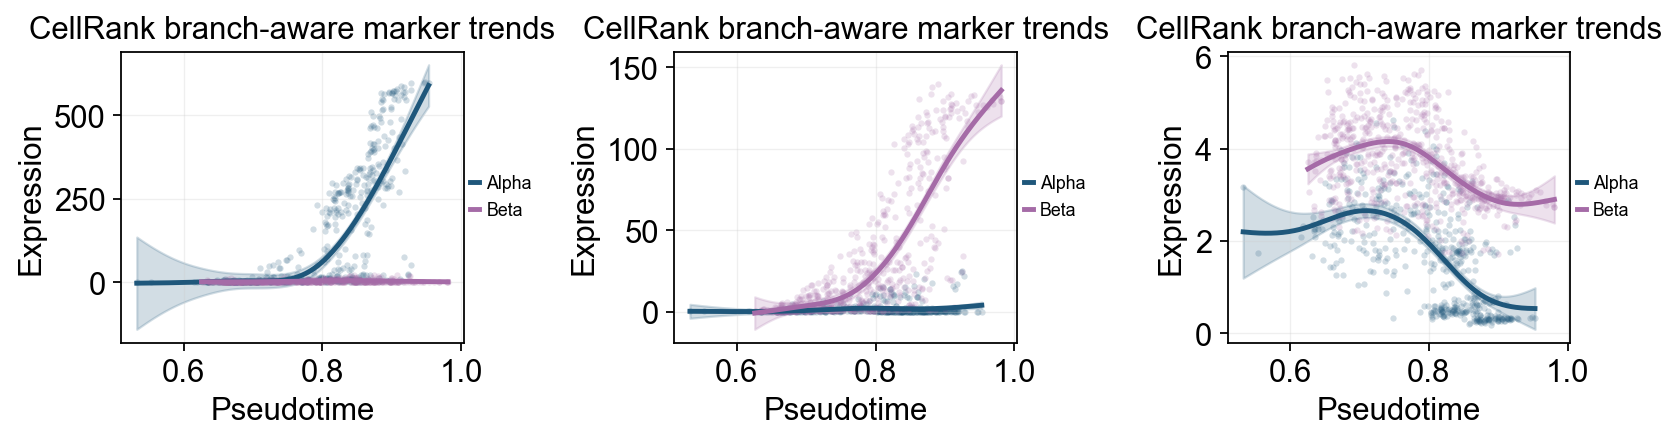

✅ Dynamic trend plotting completed!


In [21]:
ov.pl.dynamic_trends(
    cellrank_branch_dyn,
    genes=['Gcg', 'Ins2', 'Pdx1'],
    compare_groups=True,
    split_time=cellrank_split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(4.2, 3),
    linewidth=2.2,
    ncols=3,
    legend_loc='right margin',
    legend_fontsize=8,
    title='CellRank branch-aware marker trends',
)
plt.show()

## 使用 `dynamic_heatmap` 概括 marker program

同一个发育 pseudotime 也可以传给 `ov.pl.dynamic_heatmap`。这里把 marker gene 按 endocrine program 分组，并从 scVelo moments 步骤生成的 `Ms` layer 读取平滑表达量，因此这张热图可以作为上面单基因趋势图的整体补充。



🔍 Dynamic heatmap:
   Candidate features: 11
   Pseudotime: development_pseudotime
   Cell annotation: clusters
   use_fitted=True | cell_bins=180 | cmap=RdBu_r



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 11 features × 176 columns


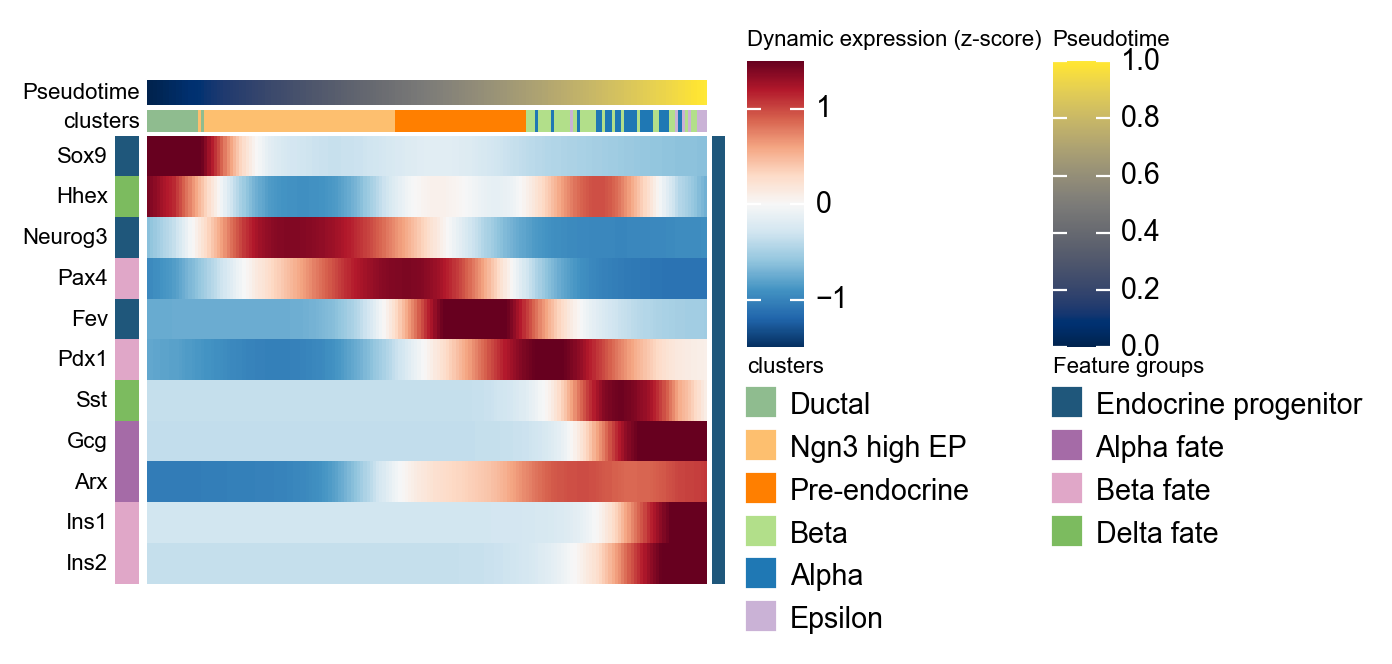

In [22]:
cellrank_marker_modules = {
    'Endocrine progenitor': ['Sox9', 'Neurog3', 'Fev'],
    'Alpha fate': ['Gcg', 'Arx'],
    'Beta fate': ['Pax4', 'Ins1', 'Ins2', 'Pdx1'],
    'Delta fate': ['Sst', 'Hhex'],
}
cellrank_marker_modules = {
    program: [gene for gene in genes if gene in adata.var_names]
    for program, genes in cellrank_marker_modules.items()
}
cellrank_marker_modules = {
    program: genes for program, genes in cellrank_marker_modules.items() if genes
}

cellrank_heatmap = ov.pl.dynamic_heatmap(
    adata,
    var_names=cellrank_marker_modules,
    pseudotime='development_pseudotime',
    layer='Ms',
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=180,
    smooth_window=17,
    fitted_window=31,
    figsize=(5, 4),
    standard_scale='var',
    cmap='RdBu_r',
    use_fitted=True,
    show_row_names=True,
    border=False,
    show=False,
)
